# train_model_tfidf_v2.ipynb
Train 4 models trên `processed_v8/` (GPS + TF-IDF 30 LSA — dedup theo list_id).

So sánh với:
- `models_v8/` — GPS + TF-IDF, dedup list_id (~40,896 rows) ← **notebook này**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import mean_squared_error, r2_score

try:
    import xgboost as xgb
except ImportError:
    os.system('pip install xgboost -q'); import xgboost as xgb

try:
    import lightgbm as lgb
except ImportError:
    os.system('pip install lightgbm -q'); import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

BASE_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..')
DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed_v8')

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val   = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
test  = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f'train: {train.shape}, val: {val.shape}, test: {test.shape}')
print(f'Columns ({len(train.columns)}): {train.columns.tolist()}')

train: (28627, 63), val: (6134, 63), test: (6135, 63)
Columns (63): ['area_m2', 'latitude', 'longitude', 'so_phong_ngu', 'so_phong_vs', 'dist_hcm_km', 'dist_hn_km', 'dist_dn_km', 'dist_bd_km', 'dist_nearest_center_km', 'title_len', 'desc_len', 'kw_mat_tien', 'kw_hem_xe_hoi', 'kw_full_nt', 'kw_so_hong', 'kw_view_song', 'kw_view_ho', 'kw_penthouse', 'kw_biet_thu', 'kw_chinh_chu', 'kw_can_ban_gap', 'lsa_0', 'lsa_1', 'lsa_2', 'lsa_3', 'lsa_4', 'lsa_5', 'lsa_6', 'lsa_7', 'lsa_8', 'lsa_9', 'lsa_10', 'lsa_11', 'lsa_12', 'lsa_13', 'lsa_14', 'lsa_15', 'lsa_16', 'lsa_17', 'lsa_18', 'lsa_19', 'lsa_20', 'lsa_21', 'lsa_22', 'lsa_23', 'lsa_24', 'lsa_25', 'lsa_26', 'lsa_27', 'lsa_28', 'lsa_29', 'loc_type_te', 'ward_te', 'district_te', 'bds__nha_o', 'bds__can_ho', 'bds__dat_nen', 'bds__van_phong', 'log_area', 'loc_area_inter', 'area_per_room', 'log_price']


## Cell 2 — Filter + tách features / targets

In [2]:
TARGET = 'log_price'

def filter_house(df):
    return df[(df['bds__nha_o'] == 1) | (df['bds__can_ho'] == 1)].copy()

train = filter_house(train)
val   = filter_house(val)
test  = filter_house(test)
print(f'Sau filter nha_o + can_ho: train={len(train):,}, val={len(val):,}, test={len(test):,}')

PRICE_UPPER = np.log1p(40_000_000_000)
train = train[train[TARGET] <= PRICE_UPPER]
val   = val[val[TARGET]     <= PRICE_UPPER]
test  = test[test[TARGET]   <= PRICE_UPPER]
print(f'Sau filter giá <= 40 tỷ : train={len(train):,}, val={len(val):,}, test={len(test):,}')

EXCLUDE = {'log_price', 'bds__dat_nen', 'bds__van_phong'}
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE]

X_train = train[FEATURE_COLS].values.astype(float)
y_train = train[TARGET].values
X_val   = val[FEATURE_COLS].values.astype(float)
y_val   = val[TARGET].values
X_test  = test[FEATURE_COLS].values.astype(float)
y_test  = test[TARGET].values

col_medians = np.nanmedian(X_train, axis=0)
for X in [X_train, X_val, X_test]:
    m = np.isnan(X)
    if m.any(): ix = np.where(m); X[ix] = np.take(col_medians, ix[1])

lsa_cols = [c for c in FEATURE_COLS if c.startswith('lsa_')]
print(f'\nX_train: {X_train.shape}')
print(f'LSA features: {len(lsa_cols)} ({lsa_cols[0]} … {lsa_cols[-1]})')
print(f'y_train: mean={y_train.mean():.3f}, std={y_train.std():.4f}')
print(f'NaN sau fill: {np.isnan(X_train).sum()}')

Sau filter nha_o + can_ho: train=18,695, val=4,047, test=4,083
Sau filter giá <= 40 tỷ : train=18,472, val=3,994, test=4,035

X_train: (18472, 60)
LSA features: 30 (lsa_0 … lsa_29)
y_train: mean=22.277, std=0.7658
NaN sau fill: 0


## Cell 3 — Metrics + PredefinedSplit

In [3]:
def rmsle(y, yp): return np.sqrt(mean_squared_error(y, yp))
def mape(yt, yp): m = yt > 0; return np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100
def mae_ty(yt, yp): return np.mean(np.abs(yt-yp))/1e9

all_results = {}

def evaluate_model(model, name):
    rows = {}
    for s, X, y in [('train',X_train,y_train), ('val',X_val,y_val), ('test',X_test,y_test)]:
        yp = model.predict(X); ytp = np.expm1(y); ypp = np.expm1(yp)
        rows[s] = dict(RMSLE=rmsle(y,yp), MAPE=mape(ytp,ypp), MAE_ty=mae_ty(ytp,ypp),
                       R2=r2_score(y,yp), y_pred_log=yp, y_true_price=ytp, y_pred_price=ypp)
    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    print(f'  {"Split":<8} {"RMSLE":>8} {"MAPE%":>8} {"MAE(tỷ)":>10} {"R²":>8}')
    print(f'  {"-"*48}')
    for s in ['train','val','test']:
        r = rows[s]
        print(f'  {s:<8} {r["RMSLE"]:>8.4f} {r["MAPE"]:>8.2f} {r["MAE_ty"]:>10.3f} {r["R2"]:>8.4f}')
    all_results[name] = rows
    return rows

X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
ps   = PredefinedSplit(np.array([-1]*len(X_train) + [0]*len(X_val)))
print('Setup OK.')

Setup OK.


## Cell 4 — Model 1: Ridge

In [4]:
gs = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
                  cv=ps, scoring='neg_root_mean_squared_error', refit=True, n_jobs=-1)
gs.fit(X_tv, y_tv)
ridge_model = Ridge(alpha=gs.best_params_['alpha'])
ridge_model.fit(X_train, y_train)
print(f'Best alpha: {gs.best_params_["alpha"]}')
ridge_results = evaluate_model(ridge_model, 'Ridge')

Best alpha: 1.0

  Ridge
  Split       RMSLE    MAPE%    MAE(tỷ)       R²
  ------------------------------------------------
  train      0.4588    38.70      2.070   0.6411
  val        0.4745    40.43      2.027   0.6239
  test       0.4501    38.48      1.991   0.6428


## Cell 5 — Model 2: Random Forest

In [5]:
rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True),
    {'n_estimators':[200,300], 'max_depth':[12,16,None],
     'min_samples_leaf':[1,2], 'max_features':['sqrt',0.5]},
    n_iter=10, cv=ps, scoring='neg_root_mean_squared_error',
    refit=False, random_state=42, n_jobs=-1, verbose=0)
rs.fit(X_tv, y_tv)
rf_model = RandomForestRegressor(**rs.best_params_, random_state=42, n_jobs=-1, oob_score=True)
rf_model.fit(X_train, y_train)
print(f'Best params: {rs.best_params_}  OOB R²={rf_model.oob_score_:.4f}')
rf_results = evaluate_model(rf_model, 'Random Forest')

Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}  OOB R²=0.7201

  Random Forest
  Split       RMSLE    MAPE%    MAE(tỷ)       R²
  ------------------------------------------------
  train      0.1493    10.60      0.722   0.9620
  val        0.4174    33.74      1.797   0.7089
  test       0.3924    30.94      1.723   0.7285


## Cell 6 — Model 3: XGBoost

In [6]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', tree_method='hist',
    n_estimators=800, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=5.0,
    early_stopping_rounds=50, random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
print(f'Best iteration: {xgb_model.best_iteration}')
xgb_results = evaluate_model(xgb_model, 'XGBoost')

Best iteration: 797

  XGBoost
  Split       RMSLE    MAPE%    MAE(tỷ)       R²
  ------------------------------------------------
  train      0.1874    13.90      0.862   0.9401
  val        0.4003    33.17      1.701   0.7323
  test       0.3759    30.19      1.660   0.7509


## Cell 7 — Model 4: LightGBM

In [7]:
lgb_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=1000, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=5.0,
    min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)])
print(f'Best iteration: {lgb_model.best_iteration_}')
lgb_results = evaluate_model(lgb_model, 'LightGBM')

[100]	training's rmse: 0.338387	valid_1's rmse: 0.422689
[200]	training's rmse: 0.279651	valid_1's rmse: 0.408595
[300]	training's rmse: 0.244176	valid_1's rmse: 0.403937
[400]	training's rmse: 0.216651	valid_1's rmse: 0.401923
[500]	training's rmse: 0.194068	valid_1's rmse: 0.400338
[600]	training's rmse: 0.174079	valid_1's rmse: 0.399413
[700]	training's rmse: 0.156154	valid_1's rmse: 0.398648
[800]	training's rmse: 0.140851	valid_1's rmse: 0.397952
[900]	training's rmse: 0.127396	valid_1's rmse: 0.397776
[1000]	training's rmse: 0.114924	valid_1's rmse: 0.397555
Best iteration: 1000

  LightGBM
  Split       RMSLE    MAPE%    MAE(tỷ)       R²
  ------------------------------------------------
  train      0.1149     8.37      0.538   0.9775
  val        0.3976    32.77      1.691   0.7359
  test       0.3737    29.98      1.645   0.7538


## Cell 8 — Feature Importance: LSA vs các features khác

XGBoost — LSA features chiếm 19.9% tổng gain
LightGBM — LSA features chiếm 29.5% tổng gain


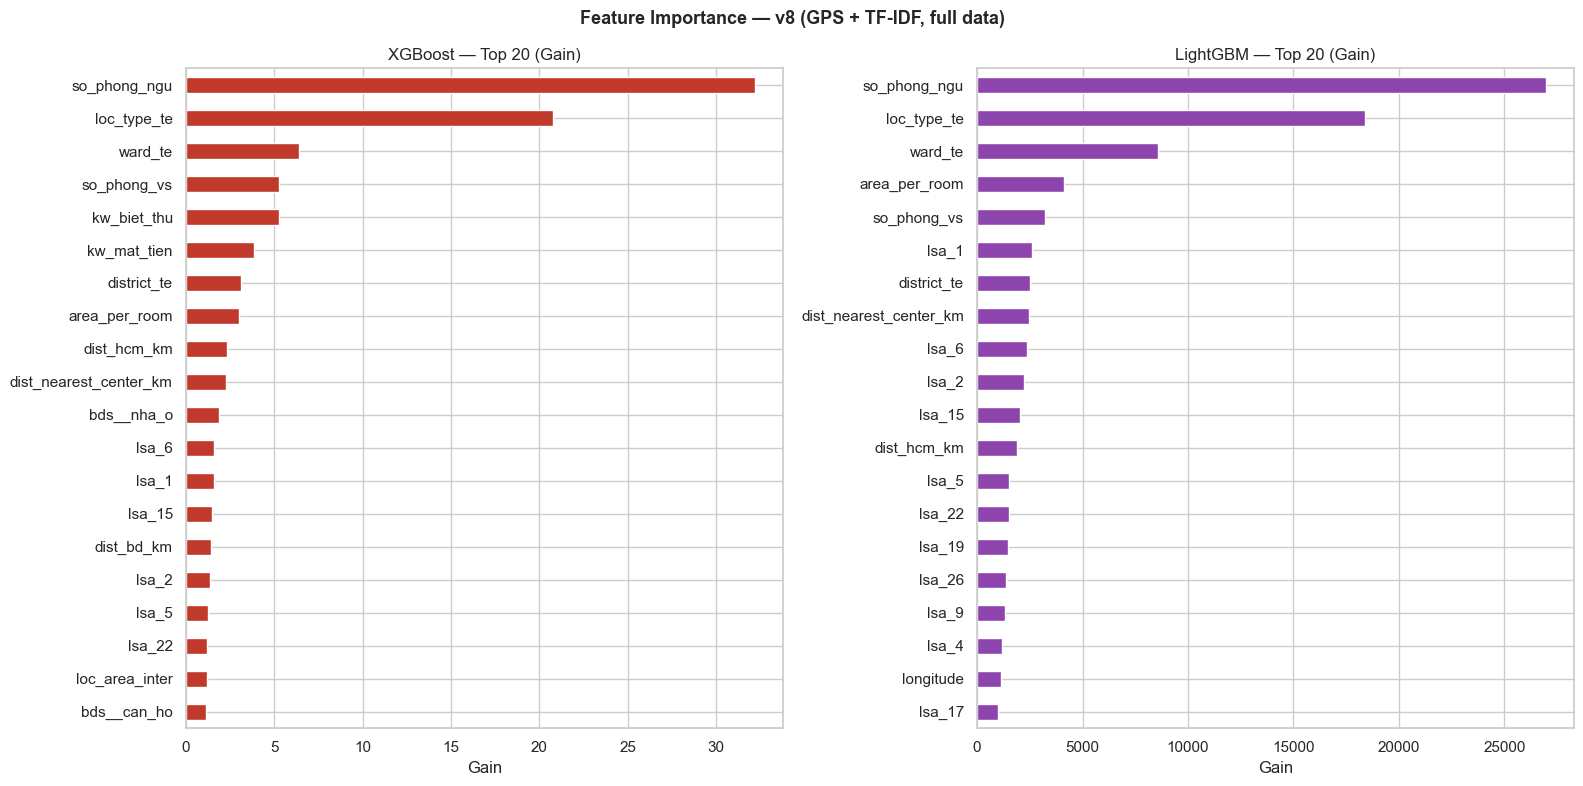


Top 5 LSA components (LightGBM rank):
  lsa_1: #6  gain=2600
  lsa_6: #9  gain=2355
  lsa_2: #10  gain=2227
  lsa_15: #11  gain=2041
  lsa_5: #13  gain=1529


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Feature Importance — v8 (GPS + TF-IDF, full data)', fontsize=13, fontweight='bold')

# XGBoost gain
booster = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type='gain')
fi_xgb = pd.Series(gain_scores).reindex(
    [f'f{i}' for i in range(len(FEATURE_COLS))]).fillna(0)
fi_xgb.index = FEATURE_COLS

lsa_importance_xgb = fi_xgb[[c for c in FEATURE_COLS if c.startswith('lsa_')]].sum()
total_xgb = fi_xgb.sum()
print(f'XGBoost — LSA features chiếm {lsa_importance_xgb/total_xgb*100:.1f}% tổng gain')

fi_xgb.nlargest(20).sort_values().plot.barh(ax=axes[0], color='#c0392b')
axes[0].set_title('XGBoost — Top 20 (Gain)')
axes[0].set_xlabel('Gain')

# LightGBM gain
fi_lgb = pd.Series(
    lgb_model.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_COLS)
lsa_importance_lgb = fi_lgb[[c for c in FEATURE_COLS if c.startswith('lsa_')]].sum()
total_lgb = fi_lgb.sum()
print(f'LightGBM — LSA features chiếm {lsa_importance_lgb/total_lgb*100:.1f}% tổng gain')

fi_lgb.nlargest(20).sort_values().plot.barh(ax=axes[1], color='#8e44ad')
axes[1].set_title('LightGBM — Top 20 (Gain)')
axes[1].set_xlabel('Gain')

plt.tight_layout()
plt.show()

lgb_sorted = fi_lgb.sort_values(ascending=False)
lsa_ranks = {col: list(lgb_sorted.index).index(col)+1
             for col in FEATURE_COLS if col.startswith('lsa_') and col in lgb_sorted.index}
top_lsa = sorted(lsa_ranks.items(), key=lambda x: x[1])[:5]
print('\nTop 5 LSA components (LightGBM rank):')
for col, rank in top_lsa:
    print(f'  {col}: #{rank}  gain={fi_lgb[col]:.0f}')

## Cell 9 — Bảng tổng hợp & Lưu models

In [9]:
rows = []
for model_name, res in all_results.items():
    rows.append({
        'Model':         model_name,
        'RMSLE_train':   res['train']['RMSLE'],
        'RMSLE_val':     res['val']['RMSLE'],
        'RMSLE_test':    res['test']['RMSLE'],
        'MAPE%_val':     res['val']['MAPE'],
        'MAE_val(tỷ)':   res['val']['MAE_ty'],
        'R²_val':        res['val']['R2'],
        'R²_test':       res['test']['R2'],   # ← thêm dòng này
    })

results_df = pd.DataFrame(rows).set_index('Model')
best_model = results_df['RMSLE_val'].idxmin()
print(f'Model tốt nhất: ★ {best_model} ★\n')
print(results_df.round(4).to_string())

MODELS_DIR = os.path.join(BASE_DIR, 'models_v8')
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(ridge_model,  os.path.join(MODELS_DIR, 'ridge.pkl'))
joblib.dump(rf_model,     os.path.join(MODELS_DIR, 'random_forest.pkl'))
joblib.dump(xgb_model,    os.path.join(MODELS_DIR, 'xgboost.pkl'))
joblib.dump(lgb_model,    os.path.join(MODELS_DIR, 'lightgbm.pkl'))
joblib.dump(FEATURE_COLS, os.path.join(MODELS_DIR, 'feature_cols.pkl'))
results_df.to_csv(os.path.join(MODELS_DIR, 'model_comparison.csv'))
print(f'\nSaved to {MODELS_DIR}')

Model tốt nhất: ★ LightGBM ★

               RMSLE_train  RMSLE_val  RMSLE_test  MAPE%_val  MAE_val(tỷ)  R²_val  R²_test
Model                                                                                     
Ridge               0.4588     0.4745      0.4501    40.4298       2.0270  0.6239   0.6428
Random Forest       0.1493     0.4174      0.3924    33.7435       1.7967  0.7089   0.7285
XGBoost             0.1874     0.4003      0.3759    33.1678       1.7008  0.7323   0.7509
LightGBM            0.1149     0.3976      0.3737    32.7750       1.6909  0.7359   0.7538

Saved to d:\Hoc kì 3\T7. Tri tue nhan tao\DA\House_Price_Prediction\Notebooks\..\models_v8


## Nhận xét:

Ridge thì có dấu hiệu underfitting, các model còn lại thì không. Đánh giá:
- Train error cao → RMSLE_train cao (Ridge = 0.456 ≈ RMSLE_test = 0.448) → R²_train thấp (thường < 0.6)
- Train ≈ Test 
-  Learning curve phẳng


Ridge là linear model — chỉ học được quan hệ tuyến tính giữa feature và giá. Nhưng giá BĐS có quan hệ phi tuyến rõ ràng nên khó trong việc dự đoán


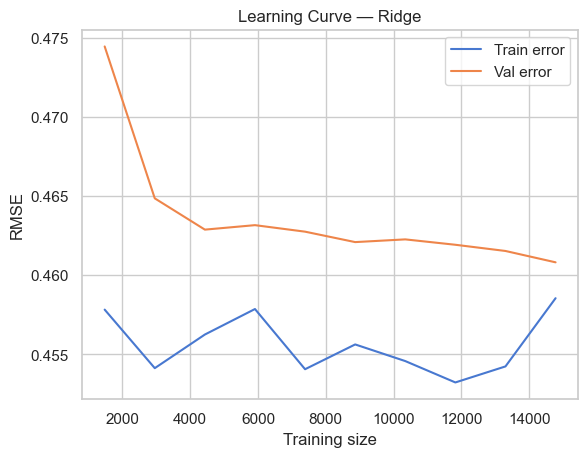

In [10]:
# Vẽ learning curve để nhìn trực quan
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    ridge_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    cv=5
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Train error')
plt.plot(train_sizes, -val_scores.mean(axis=1),   label='Val error')
plt.legend()
plt.title('Learning Curve — Ridge')
plt.xlabel('Training size')
plt.ylabel('RMSE')
plt.show()

Random Forest / XGBoost / LightGBM — Overfitting nhẹ:


Trong đó LightGBM:
- RMSLE_train = 0.1542   ← rất thấp (học gần như thuộc train)
- RMSLE_val   = 0.3980   ← cao hơn train 2.6x
- Gap         = 0.2438   ← gap lớn → overfitting
- R²_val      = 0.7354   ← vẫn tốt → overfitting chưa nghiêm trọng